In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)

In [3]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

def convertAxis(df):    
    for col in ['ax', 'ay', 'az']:
        df[col] = df[col] / 1000000.0 * 9.80665

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df

,wx,roll,az,yaw,tmp,wz,ax,time,pitch,wy,ay,h
0,0.83430,-179.586,-9.904295,216.937,38.1,0.34976,-0.024399,2.384186e-07,3.030,-0.37456,0.710511,0.0
1,1.33490,-179.586,-9.861028,216.935,38.1,-0.17682,-0.012503,1.034784e-02,3.018,0.11475,0.697969,0.0
2,1.78830,-179.582,-9.846004,216.930,38.1,-0.53601,0.037265,2.220368e-02,3.001,0.38014,0.639276,0.0
3,1.95598,-179.580,-9.859773,216.922,38.3,-0.75341,0.053780,3.249288e-02,2.981,0.33900,0.650799,0.0
4,2.55846,-179.577,-9.839865,216.913,38.1,-0.86933,0.044493,4.263878e-02,2.956,0.37000,0.650612,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
26643,0.00846,98.337,-1.359604,107.883,37.3,0.09794,-9.325036,4.208905e+02,15.869,-0.05616,2.675225,0.0
26644,0.04313,98.337,-1.358005,107.884,37.0,0.01813,-9.329302,4.209121e+02,15.869,0.04077,2.676951,0.0
26645,-0.02175,98.337,-1.366282,107.884,37.1,-0.01022,-9.308982,4.209230e+02,15.869,0.04838,2.679598,0.0
26646,-0.00333,98.337,-1.369234,107.884,37.1,-0.02863,-9.312228,4.209459e+02,15.869,-0.04573,2.675078,0.0


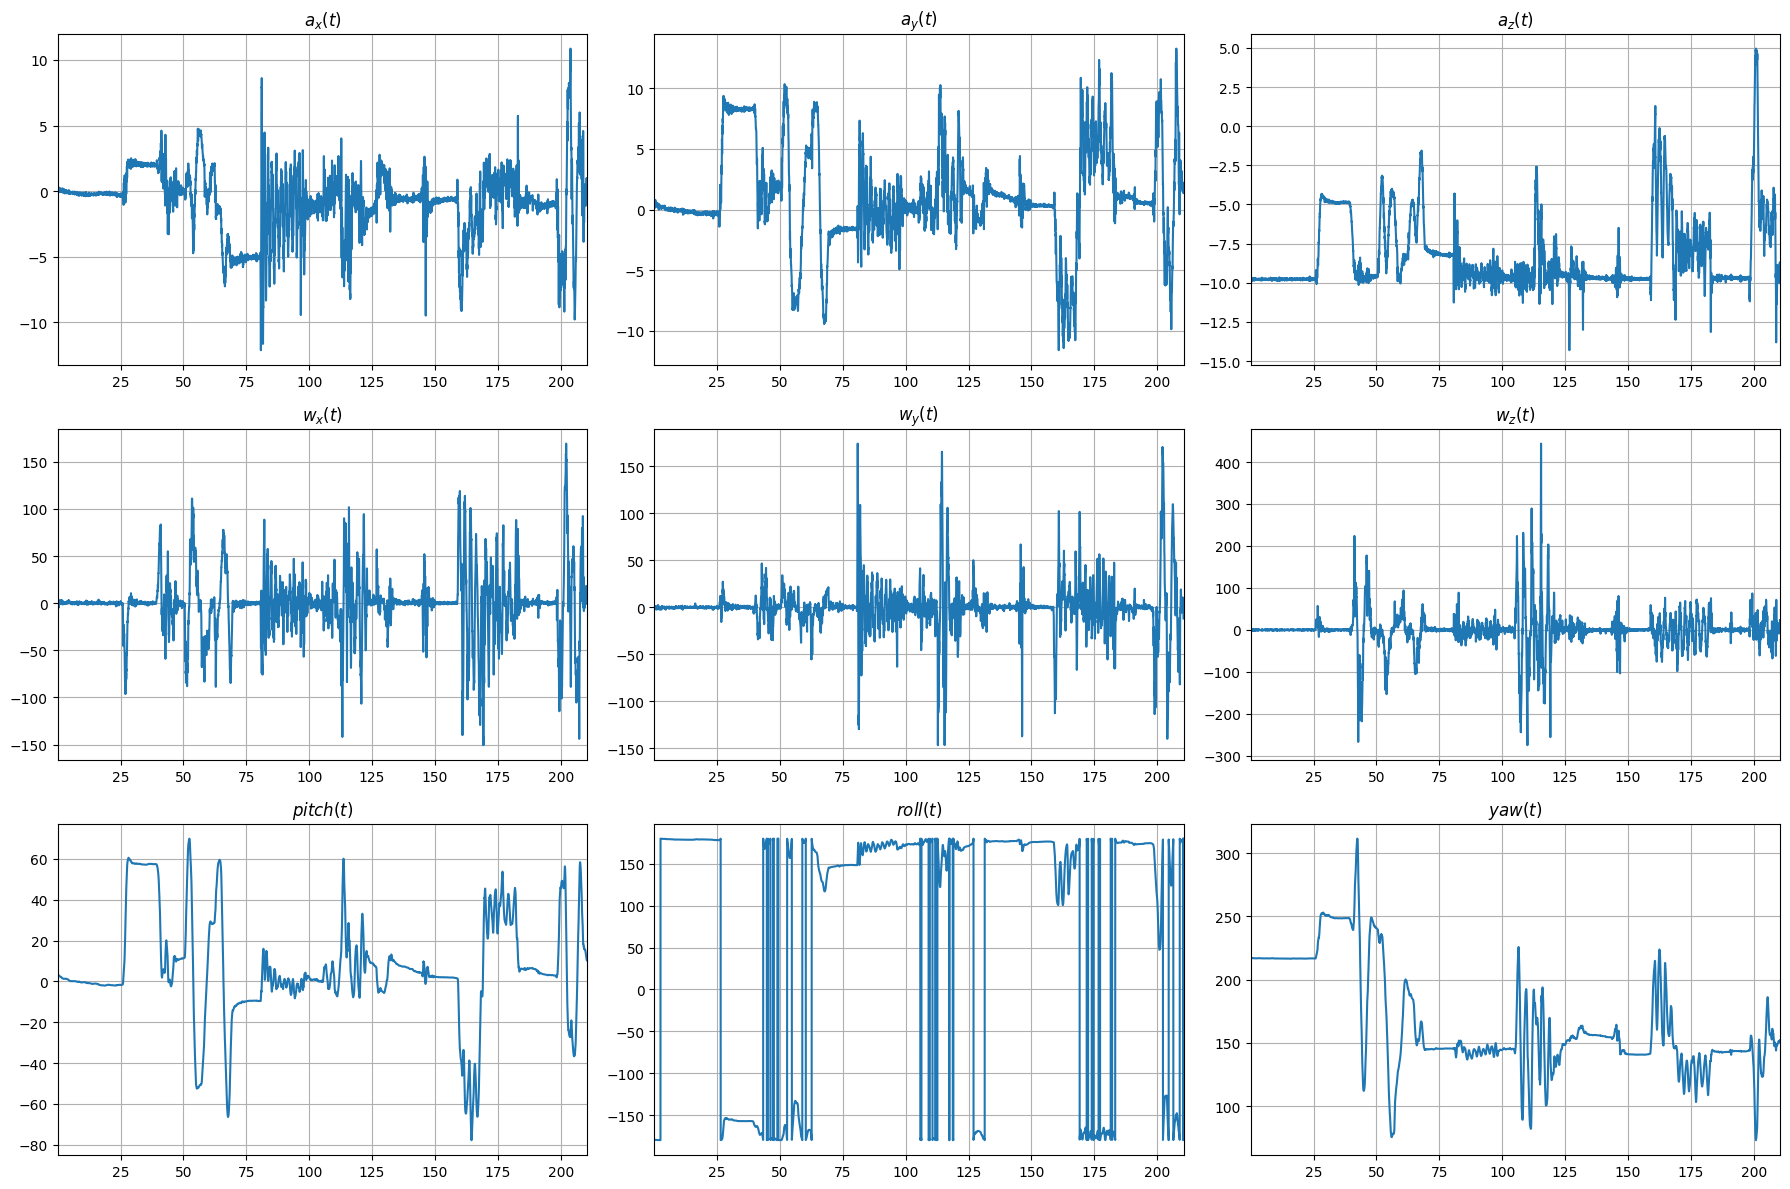

In [5]:
df = convertAxis(pd.read_csv('docs/DataBase.csv'))
display(df)
plotAll(df, limits=(0, 0.5))